In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
CUDA_LAUNCH_BLOCKING=1
def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values


cuda:1


In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  # Number of grid cells in the x direction
nx,ny=3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 # On boundary Gamma

num_batches_gauss=1
b_n=15
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.5,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
S_int_true_circle,F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle=generate_data.boundary_data_circle(kk,number_gene,points_b,f_circle,x_left,x_right,y_below,y_upper,center_true,r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
F=inverse_solver.F(F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
R_m=20
r_low,r_upper=0.18,0.2
b_below,b_upper=-0.51,-0.49


/data1/hxw-b25/MA-RFM/Ex4.3/../main_code/2d/generate_data.py:474: PerformanceWarning: The device where the array resides (0) is different from the current device (1). Peer access has been activated automatically.
  w_sol_y1=self._geom_factor()*result_y1*self.w
/data1/hxw-b25/MA-RFM/Ex4.3/../main_code/2d/generate_data.py:498: PerformanceWarning: The device where the array resides (0) is different from the current device (1). Peer access has been activated automatically.
  w_sol_y2=self._geom_factor()*result_y2*self.w
/data1/hxw-b25/MA-RFM/Ex4.3/../main_code/2d/generate_data.py:448: PerformanceWarning: The device where the array resides (0) is different from the current device (1). Peer access has been activated automatically.
  w_sol=self._geom_factor()*self.Phi*self.w


In [3]:
M=800
af="Tanh"   # Initial activation setting
R_m=20
cupy_device = device.index if device.type == "cuda" else 0
#models = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
models = net_2d.local_rep(2,1,1,M,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


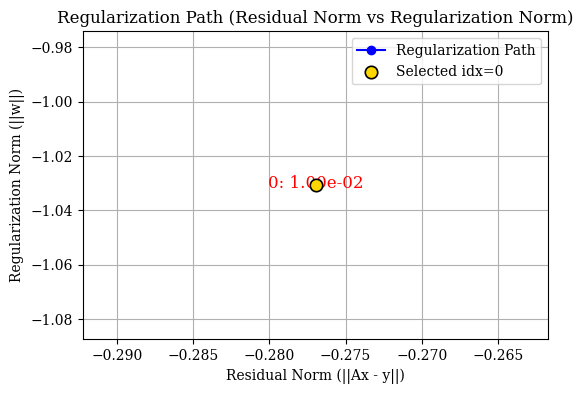

Training error at iteration 0 :
Generalization error at iteration 0 :


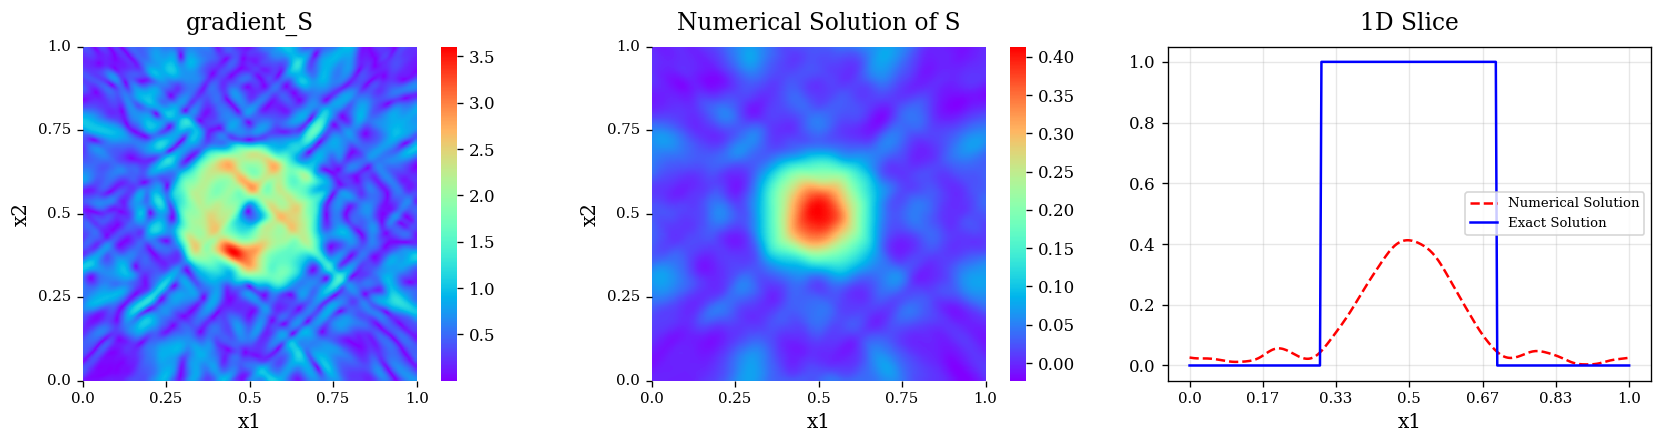

S_l_inf= 2.7634870794549786 S_L_2= 0.28723293631327024 S_l_2= 0.8139325926284973
Adaptive mesh refinement at iteration 0 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


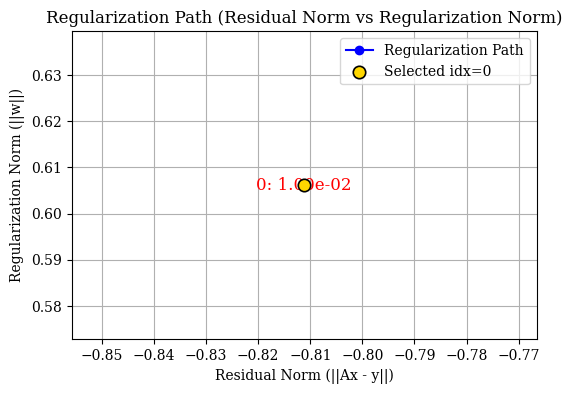

Training error at iteration 1 :
Generalization error at iteration 1 :


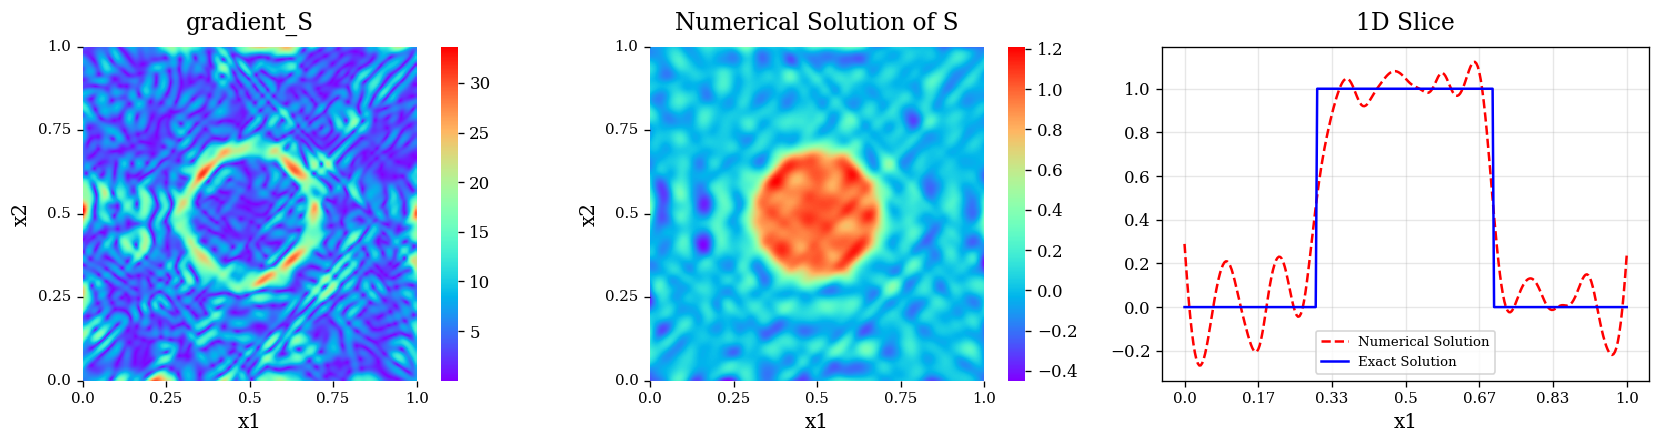

S_l_inf= 2.0237805504981745 S_L_2= 0.12277922105277678 S_l_2= 0.3479197441459188
Adaptive mesh refinement at iteration 1 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


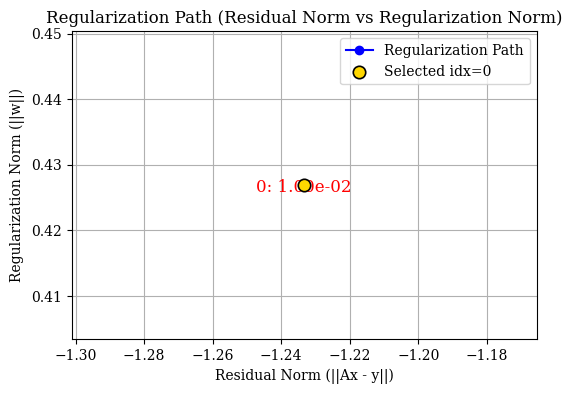

Training error at iteration 2 :
Generalization error at iteration 2 :


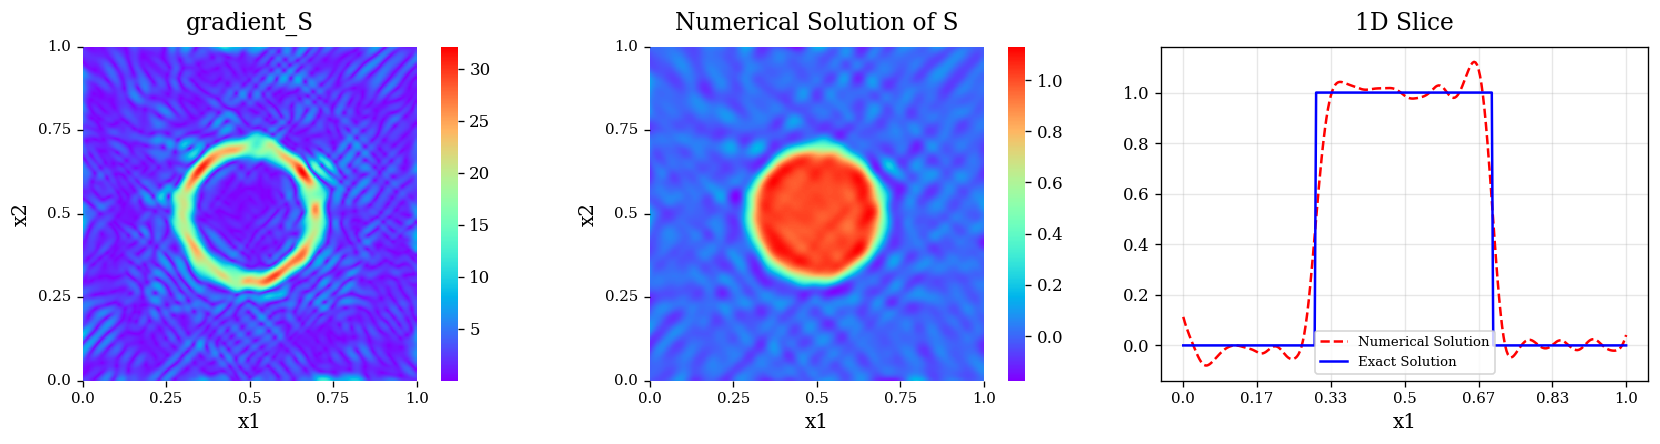

S_l_inf= 1.684203263946946 S_L_2= 0.07920564991734239 S_l_2= 0.22444522141338136
Adaptive mesh refinement at iteration 2 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


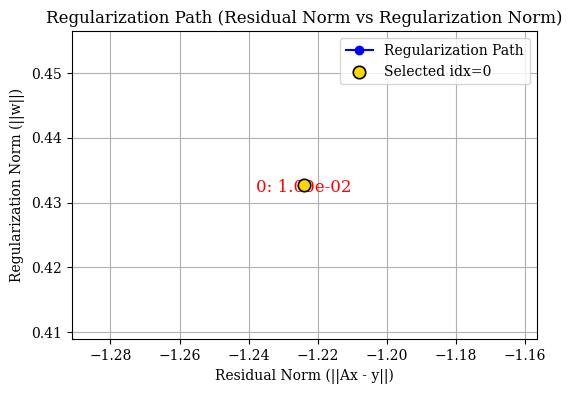

Training error at iteration 3 :
Generalization error at iteration 3 :


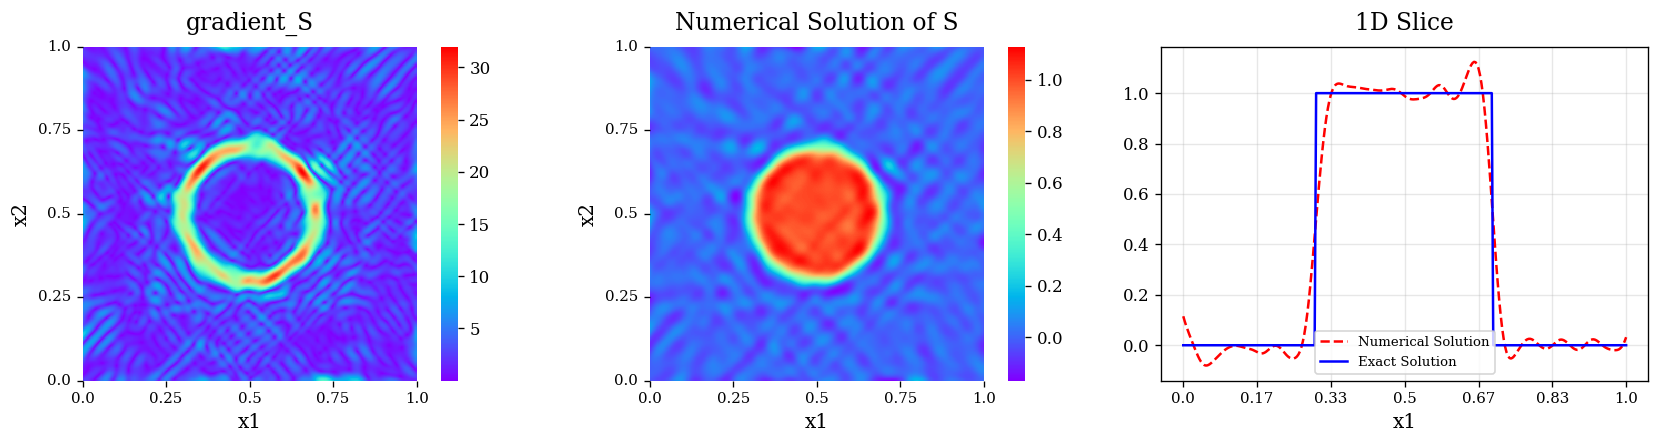

S_l_inf= 1.66651389629377 S_L_2= 0.07940700257027317 S_l_2= 0.22501579486131573
Adaptive mesh refinement at iteration 3 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


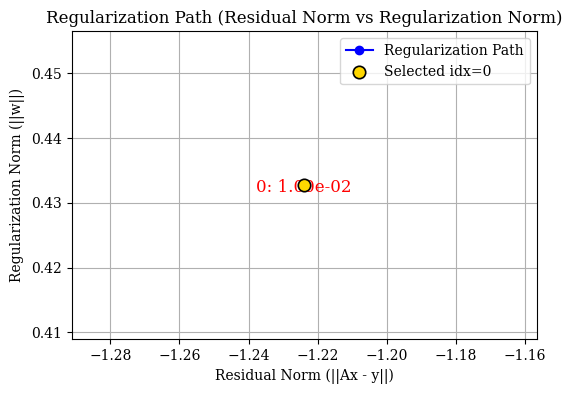

Training error at iteration 4 :
Generalization error at iteration 4 :


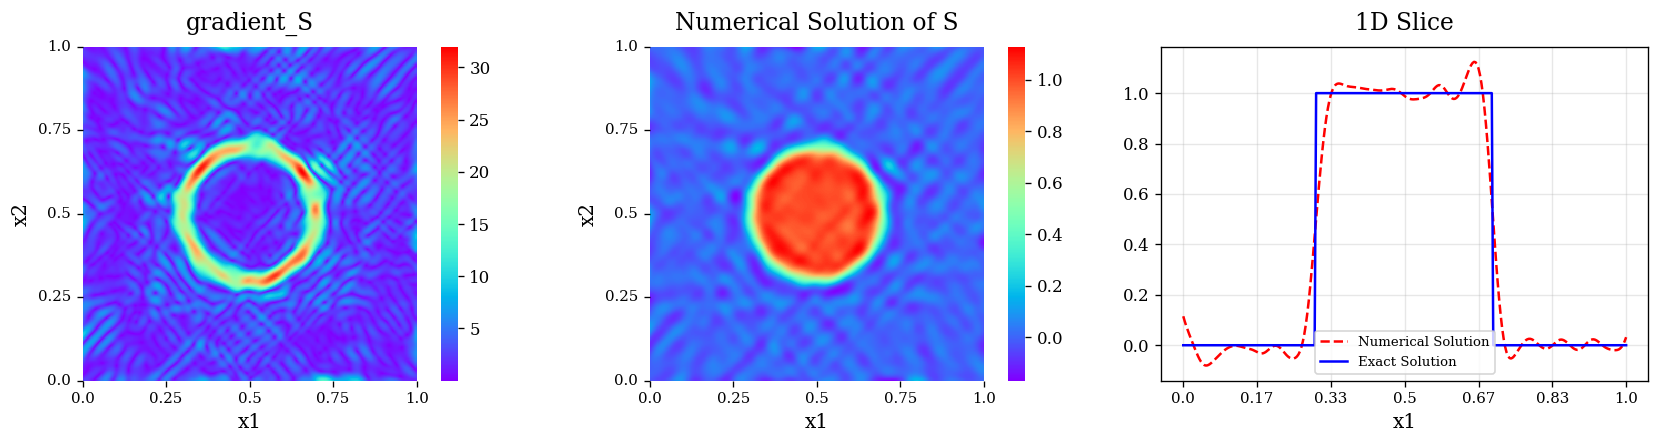

S_l_inf= 1.6664469232341228 S_L_2= 0.07940714594192008 S_l_2= 0.22501620113386156
Stop at iteration 4


In [4]:
iter_int= 5
Ix,Iy=4,4  # Number of grid cells in the x direction
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"

refine_threshold_S=1/100
refine_threshold_grad=1/300
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main.ada_int_fix(iter_int,delta,cells,nx,models,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,f_circle,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)


In [5]:
len(cells_store[-1])

742

In [6]:
# Save cell_stores
import pickle
with open('./MA_RFM_5%/M=800*2_5%/cells_store.pkl', 'wb') as f:
    pickle.dump(cells_store, f)

DBSCAN eps = 0.016667 (5.000000 * h, h = 0.003333)
Number of detected clusters: 1
  CV of S_num: 0.261
Cluster 0: AR=1.01
  Res_Rect=0.089923 vs Res_Ellip=0.013355
  center=(0.5004, 0.5001)
  -> Decision: Ellipsoid (Sigmoid)


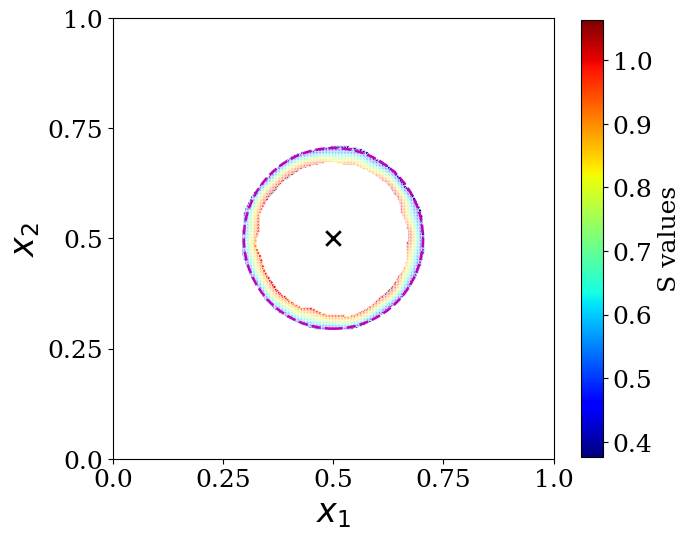

LaTeX table rows:
{\emph{Ex}} & Cluster $k$ & $\boldsymbol{c}_k$ & $r_k$ or $\boldsymbol{L}_k$ & $\mathcal{E}_{\mathrm{rect}}^{(k)}$ & $\mathcal{E}_{\mathrm{ellip}}^{(k)}$ & $\mathrm{AR}_k$ & $\mathrm{CV}_k$ & $\mathcal{T}_k$ & $\sigma_k$ \\
Ex 4.3 & 1 & (5.00e-01, 5.00e-01) & $\boldsymbol{L}$=(2.03e-01, 2.05e-01) & 0.0899 & 0.0134 & 1.01 & 0.261 & \textbf{Ellipsoid} & Sigmoid \\


['{\\emph{Ex}} & Cluster $k$ & $\\boldsymbol{c}_k$ & $r_k$ or $\\boldsymbol{L}_k$ & $\\mathcal{E}_{\\mathrm{rect}}^{(k)}$ & $\\mathcal{E}_{\\mathrm{ellip}}^{(k)}$ & $\\mathrm{AR}_k$ & $\\mathrm{CV}_k$ & $\\mathcal{T}_k$ & $\\sigma_k$ \\\\',
 'Ex 4.3 & 1 & (5.00e-01, 5.00e-01) & $\\boldsymbol{L}$=(2.03e-01, 2.05e-01) & 0.0899 & 0.0134 & 1.01 & 0.261 & \\textbf{Ellipsoid} & Sigmoid \\\\']

In [9]:
from importlib import reload
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5.0
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./MA_RFM_5%/M=800*2_5%", output_filename="plot.png", eps_mode="grid_scaled")
print("LaTeX table rows:")
bound_detect.print_latex_result_rows(results, example_name="Ex 4.3", include_header=True)


In [8]:
results

[{'cluster_id': 0,
  'shape': 'Ellipsoid',
  'params': {'center': array([0.5003778 , 0.50023449]),
   'a': np.float64(0.20333333333333334),
   'b': np.float64(0.20500000000000002),
   'radius': 0.20339321903150964},
  'profile': 'Sigmoid',
  'boundary_points': array([[0.49617667, 0.29032333],
         [0.49556667, 0.29093333],
         [0.49495667, 0.29093333],
         ...,
         [0.49800667, 0.29032333],
         [0.49739667, 0.29032333],
         [0.49678667, 0.29032333]]),
  'diagnostics': {'Lx': 0.4066666666666667,
   'Ly': 0.41000000000000003,
   'aspect_ratio': 1.0081967213114755,
   'res_rect': 0.09170631129336562,
   'res_ellip': 0.011452191501243261,
   'residual_threshold': 0.05,
   'tori_ratio': 0.783330520453938,
   'r_mean': 0.18875450836125632,
   'min_dist_to_center': 0.16224716352749916,
   'max_dist_to_center': 0.20712478231216797,
   'dist_05': 0.17322357489593646,
   'dist_95': 0.20339321903150964},
  'aspect_ratio': 1.0081967213114755,
  'res_rect': 0.0917063112

In [9]:
ellip_entry = next((item for item in results if item.get("shape") == "Ellipsoid"), results[0])
center = np.asarray(ellip_entry["params"]["center"])
a_ellip = float(ellip_entry["params"].get("a", ellip_entry["params"].get("radius")))
b_ellip = float(ellip_entry["params"].get("b", ellip_entry["params"].get("radius")))
r_equiv = float(ellip_entry["params"].get("radius", max(a_ellip, b_ellip)))


In [19]:
theta_min, theta_max = -1e-12, 1e-12
K_old_min = 1000
K_old_max = 20000
# Use the paper's 2D nondimensional K mapping for the ellipse branch:
#   K_ellip = (a*b) * K_old, with semi-axes a and b.
ellip_char = a_ellip * b_ellip
K_min = ellip_char * K_old_min
K_max = ellip_char * K_old_max

def _ordered_bounds(v1, v2):
    return (min(float(v1), float(v2)), max(float(v1), float(v2)))

b1_min, b1_max = _ordered_bounds(center[0] * (1 - 0.05), center[0] * (1 + 0.05))
b2_min, b2_max = _ordered_bounds(center[1] * (1 - 0.05), center[1] * (1 + 0.05))
axis_a_min, axis_a_max = _ordered_bounds(a_ellip * (1 - 0.1), a_ellip * (1 + 0.05))
axis_b_min, axis_b_max = _ordered_bounds(b_ellip * (1 - 0.1), b_ellip * (1 + 0.05))
models1 = models
models2 = net_2d.local_rep(
    2, 1, 1, M,
    tau_x_min, tau_x_max, tau_y_min, tau_y_max,
    theta_min, theta_max,
    b1_min, b1_max, b2_min, b2_max,
    axis_a_min, axis_a_max, axis_b_min, axis_b_max,
    [], [], [], [], K_min, K_max,
    R_m_for_init=R_m, af="sigmoid", Shape="ellipsoid", device=device,
).to(device)
af = "mix"
sum_mat, all_g_p1, all_g_n, cells_copy1, rrr, sss = matrix_assemble.mat_assemble(
    cells_store[-1], models1, models2, [], "mix", "ellipsoid", [], kk, 0, points_b, 0, device, cupy_device
)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


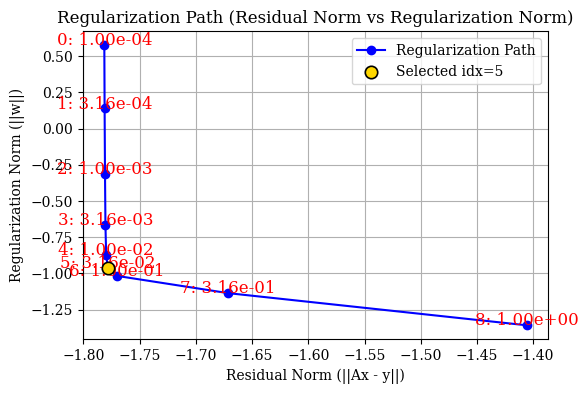

In [20]:
lamb_regu=np.logspace(-4,0,9,endpoint=True)
res,reg_norm,w_store=inverse_solver.L_curve(sum_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=5.652456e-02
  idx=5, lambda=3.162278e-02, curvature=2.327653e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=2.078780e+00
candidate idx: [4 5 6]
candidate lambda: [0.01       0.03162278 0.1       ]


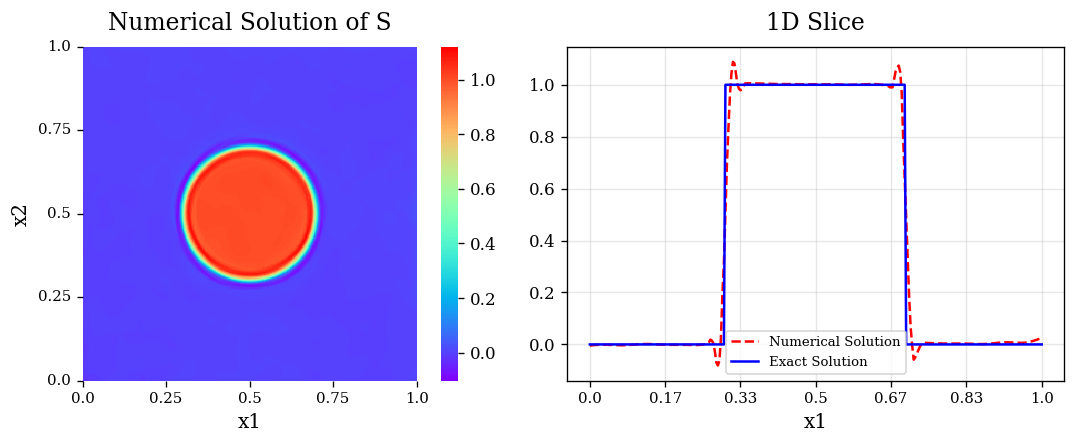

S_l_inf= 1.5254726544277126 S_L_2= 0.04804811286891377 S_l_2= 0.13615404131665682
candidate idx=4, lamb=0.0001, S_l_inf=1.5254726544277126, S_l_2=0.13615404131665682


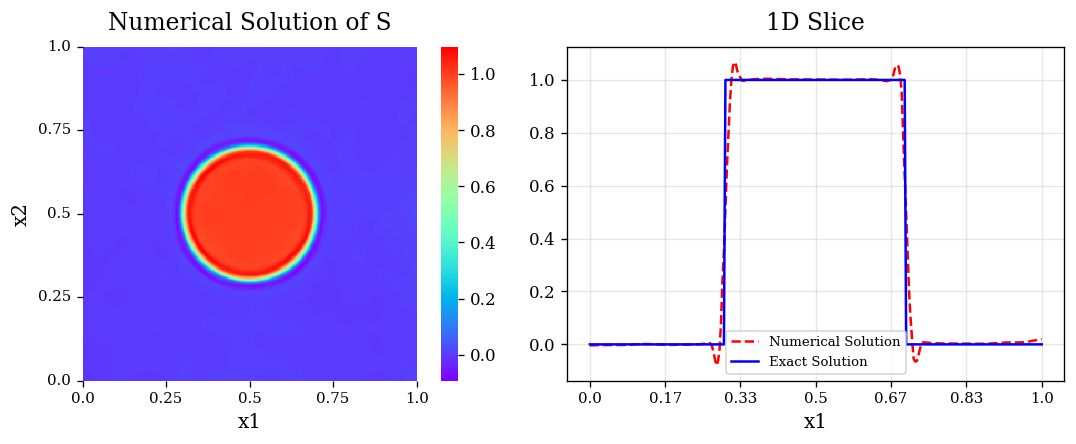

S_l_inf= 1.5341672271538531 S_L_2= 0.05023070957930672 S_l_2= 0.1423388703336712
candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.5341672271538531, S_l_2=0.1423388703336712


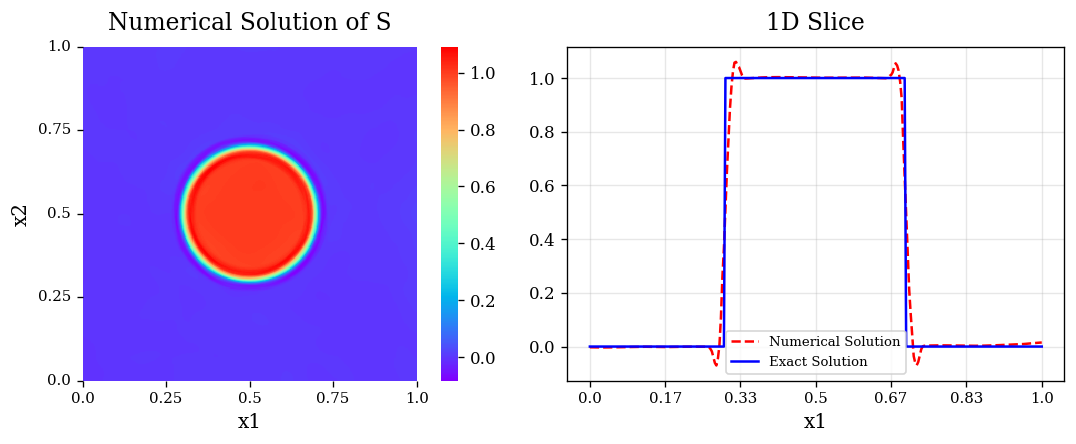

S_l_inf= 1.5255390300807217 S_L_2= 0.05217009758844812 S_l_2= 0.1478345183281319
candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.5255390300807217, S_l_2=0.1478345183281319
picked idx: 4
lamb: 0.0001


In [21]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_2d.test(models1,models2,[],M,Qx,Qy,cand_w,af,"ellipsoid",[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,f_circle,0,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)


In [22]:
torch.save(models1,"./MA_RFM_5%/M=800*2_5%/models1_800.pth")

In [23]:
torch.save(models2,"./MA_RFM_5%/M=800*2_5%/models1_sig_33_800.pth")

In [24]:
np.save("./MA_RFM_5%/M=800*2_5%/g_S",g_S)
np.save("./MA_RFM_5%/M=800*2_5%/S_l2",S_l2)
np.save("./MA_RFM_5%/M=800*2_5%/S_num_store",S_num_store)
np.save("./MA_RFM_5%/M=800*2_5%/S_num_MA-RFM_800",S_test_num)
np.save("./MA_RFM_5%/M=800*2_5%/all_mat",sum_mat)
np.save("./MA_RFM_5%/M=800*2_5%/w_store",w_store)
np.save("./MA_RFM_5%/M=800*2_5%/F_mea_b",F_mea_b_circle)
np.save("./MA_RFM_5%/M=800*2_5%/F_mea_db_x1",F_mea_db_x1_circle)
np.save("./MA_RFM_5%/M=800*2_5%/F_mea_db_x2",F_mea_db_x2_circle)

In [25]:
parameters0 = {
    "I_grid":Ix,
    "gauss_n":nx,
    "number_gene":number_gene,
    "noise":eps,
    "k": kk,
    "M0": M,
    "M1": M,
    "Tanh_Rm":20,
    "Gauss_R_m": R_m,
    "refinement_stats_store":refinement_stats_store,
    "points_number_ada:":point_number,
    "center":center,
    "a_ellip": a_ellip,
    "b_ellip": b_ellip,
    "r_equiv": r_equiv,
    "theta_min": theta_min,
    "theta_max": theta_max,
    "b1_min": b1_min,
    "b1_max": b1_max,
    "b2_min": b2_min,
    "b2_max": b2_max,
    "axis_a_min": axis_a_min,
    "axis_a_max": axis_a_max,
    "axis_b_min": axis_b_min,
    "axis_b_max": axis_b_max,
    "K_old_min": K_old_min,
    "K_old_max": K_old_max,
    "ellip_char": ellip_char,
    "K_min": K_min,
    "K_max": K_max,
}


In [26]:
import pickle # Import the pickle module
output_pickle_file = "./MA_RFM_5%/M=800*2_5%/parameters.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(parameters0, f)

In [27]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center:',center)


print('a_ellip:', a_ellip)
print('b_ellip:', b_ellip)
print('r_equiv:', r_equiv)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)


n_integral: 6705
center: [0.5003778  0.50023449]
a_ellip: 0.20333333333333334
b_ellip: 0.20500000000000002
r_equiv: 0.20339321903150964
S_l2[-1]: 0.22071332145476283
lamb_regu: 0.0001
S_l21: 0.13615404131665682
